# Figure 2 Dependency-Ratio Panel Test

Scratch notebook for testing a four-panel Figure 2 layout. It does not save figure files. The dependency-ratio panel is computed as `(0-14 + 65+) / 15-64` for each elevation group and settlement class, using the static-2025 analysis-ready release table one directory above this repository.

In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

%matplotlib inline

ROOT = Path.cwd()
if not (ROOT / 'data' / 'dataset_s1_hypsographic_demography.csv').exists():
    ROOT = Path('/Users/f6z/Documents/projects/montana_state/hypsographic_demography')

DATA = ROOT / 'data'
TAB = ROOT / 'outputs' / 'tables'

ELEVATION_ORDER = ['<100 m', '100-499 m', '500-1499 m', '1500-2499 m', '2500-3499 m', '>=3500 m']
SETTLEMENT_ORDER = ['Low-density rural', 'Rural cluster', 'Peri-urban', 'Semi-dense urban', 'Dense urban', 'Urban centre']
ELEVATION_LABELS = {
    '<100 m': '<100 m',
    '100-499 m': '100-499 m',
    '500-1499 m': '500-1,499 m',
    '1500-2499 m': '1,500-2,499 m',
    '2500-3499 m': '2,500-3,499 m',
    '>=3500 m': '>=3,500 m',
}
PNAS_FULL_WIDTH_IN = 17.8 / 2.54

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if 'Helvetica' in available_fonts:
    FIGURE_FONT = 'Helvetica'
elif 'Arial' in available_fonts:
    FIGURE_FONT = 'Arial'
else:
    FIGURE_FONT = 'DejaVu Sans'

mpl.rcParams.update({
    'font.family': FIGURE_FONT,
    'font.size': 6.2,
    'axes.titlesize': 6.9,
    'axes.labelsize': 6.4,
    'xtick.labelsize': 5.4,
    'ytick.labelsize': 5.6,
    'legend.fontsize': 5.6,
    'axes.linewidth': 0.55,
    'figure.dpi': 220,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

def panel_label(ax, label):
    ax.text(
        -0.12, 1.08, label,
        transform=ax.transAxes,
        fontsize=8.0,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

def annotate_matrix(ax, data, cmap, norm, fmt='{:.1f}', fontsize=4.5):
    arr = np.asarray(data, dtype=float)
    cmap_obj = mpl.colormaps[cmap] if isinstance(cmap, str) else cmap
    if not np.isfinite(arr).any():
        return
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                r, g, b, _ = cmap_obj(norm(val))
                luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
                color = 'white' if luminance < 0.50 else '0.12'
                ax.text(j, i, fmt.format(val), ha='center', va='center', fontsize=fontsize, color=color)

def minmax_norm(data):
    arr = np.asarray(data, dtype=float)
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return mpl.colors.Normalize(vmin=0, vmax=1)
    return mpl.colors.Normalize(vmin=float(finite.min()), vmax=float(finite.max()))


In [17]:
main_fig02_static = pd.read_csv(TAB / 'main_fig02_static2025_data.csv')
dependency_preview_note = ''

demographic_source_candidates = [
    ROOT.parent / 'hypsographic_demography_download_data' / 'data' / 'static_2025' / 'fact_enriched_demographic_metrics.parquet',
    ROOT.parent / 'hypsographic_demography_public_release_v1' / 'data' / 'static_2025' / 'fact_enriched_demographic_metrics.parquet',
]
demographic_source = next((path for path in demographic_source_candidates if path.exists()), None)
if demographic_source is None:
    raise FileNotFoundError('Could not find static_2025/fact_enriched_demographic_metrics.parquet one level above this repository.')

metrics_cols = [
    'year', 'elevation_bin', 'smod_label', 'population_total',
    'youth_population', 'working_age_population', 'old_age_population',
    'male_population', 'female_population',
]
metrics = pd.read_parquet(demographic_source, columns=metrics_cols)
metrics = metrics[
    metrics['year'].eq(2025)
    & metrics['smod_label'].notna()
    & ~metrics['smod_label'].eq('water')
].copy()

elevation_bin_to_group = {
    '<0': '<100 m', '0-9': '<100 m', '10-49': '<100 m', '50-99': '<100 m',
    '100-199': '100-499 m', '200-299': '100-499 m', '300-399': '100-499 m', '400-499': '100-499 m',
    '500-999': '500-1499 m', '1000-1499': '500-1499 m',
    '1500-1999': '1500-2499 m', '2000-2499': '1500-2499 m',
    '2500-2999': '2500-3499 m', '3000-3499': '2500-3499 m',
    '3500-3999': '>=3500 m', '4000-4499': '>=3500 m', '4500-4999': '>=3500 m',
    '5000-5499': '>=3500 m', '5500-5999': '>=3500 m', '6000-6499': '>=3500 m',
    '6500-6999': '>=3500 m', '7000-7499': '>=3500 m', '7500-7999': '>=3500 m', '8000+': '>=3500 m',
}
smod_to_settlement = {
    'very_low_density_rural': 'Low-density rural',
    'low_density_rural': 'Low-density rural',
    'rural_cluster': 'Rural cluster',
    'suburban_or_peri_urban': 'Peri-urban',
    'semi_dense_urban_cluster': 'Semi-dense urban',
    'dense_urban_cluster': 'Dense urban',
    'urban_centre': 'Urban centre',
}
metrics['elevation_group'] = metrics['elevation_bin'].map(elevation_bin_to_group)
metrics['settlement_class'] = metrics['smod_label'].map(smod_to_settlement)
if metrics[['elevation_group', 'settlement_class']].isna().any().any():
    missing_labels = metrics.loc[
        metrics[['elevation_group', 'settlement_class']].isna().any(axis=1),
        ['elevation_bin', 'smod_label'],
    ].drop_duplicates()
    raise ValueError(f'Unmapped labels in demographic source:\n{missing_labels}')

dependency_source = (
    metrics
    .groupby(['elevation_group', 'settlement_class'], as_index=False)[
        ['population_total', 'youth_population', 'working_age_population', 'old_age_population', 'male_population', 'female_population']
    ]
    .sum()
)
dependency_source['dependency_ratio'] = (
    dependency_source['youth_population'] + dependency_source['old_age_population']
) / dependency_source['working_age_population']
dependency_source['upstream_youth_share_percent'] = 100 * dependency_source['youth_population'] / dependency_source['population_total']
dependency_source['upstream_male_share_percent'] = 100 * dependency_source['male_population'] / dependency_source['population_total']

fig2_test = main_fig02_static.merge(
    dependency_source[[
        'elevation_group', 'settlement_class', 'population_total', 'youth_population',
        'upstream_youth_share_percent', 'upstream_male_share_percent', 'dependency_ratio',
    ]],
    on=['elevation_group', 'settlement_class'],
    how='left',
    suffixes=('', '_upstream'),
)
if fig2_test['dependency_ratio'].isna().any():
    missing = fig2_test.loc[fig2_test['dependency_ratio'].isna(), ['elevation_group', 'settlement_class']]
    raise ValueError(f'Missing dependency-ratio cells after merge:\n{missing}')

qc = {
    'population_2025_max_abs_diff': (fig2_test['population_total'] - fig2_test['pop_2025_static2025']).abs().max(),
    'youth_population_max_abs_diff': (fig2_test['youth_population_upstream'] - fig2_test['youth_population']).abs().max(),
    'youth_share_max_abs_diff': (fig2_test['upstream_youth_share_percent'] - fig2_test['youth_share_percent']).abs().max(),
    'male_share_max_abs_diff': (fig2_test['upstream_male_share_percent'] - fig2_test['male_share_percent']).abs().max(),
}
print(f'Dependency source: {demographic_source}')
print('QC against existing Figure 2 table:', qc)
fig2_test[['elevation_group', 'settlement_class', 'dependency_ratio']].head()


Dependency source: /Users/f6z/Documents/projects/montana_state/hypsographic_demography_download_data/data/static_2025/fact_enriched_demographic_metrics.parquet
QC against existing Figure 2 table: {'population_2025_max_abs_diff': np.float64(3.725290298461914e-09), 'youth_population_max_abs_diff': np.float64(1.4901161193847656e-08), 'youth_share_max_abs_diff': np.float64(7.105427357601002e-15), 'male_share_max_abs_diff': np.float64(7.105427357601002e-15)}


,elevation_group,settlement_class,dependency_ratio
0,<100 m,Low-density rural,0.539955
1,<100 m,Rural cluster,0.558845
2,<100 m,Peri-urban,0.519814
3,<100 m,Semi-dense urban,0.533673
4,<100 m,Dense urban,0.537153


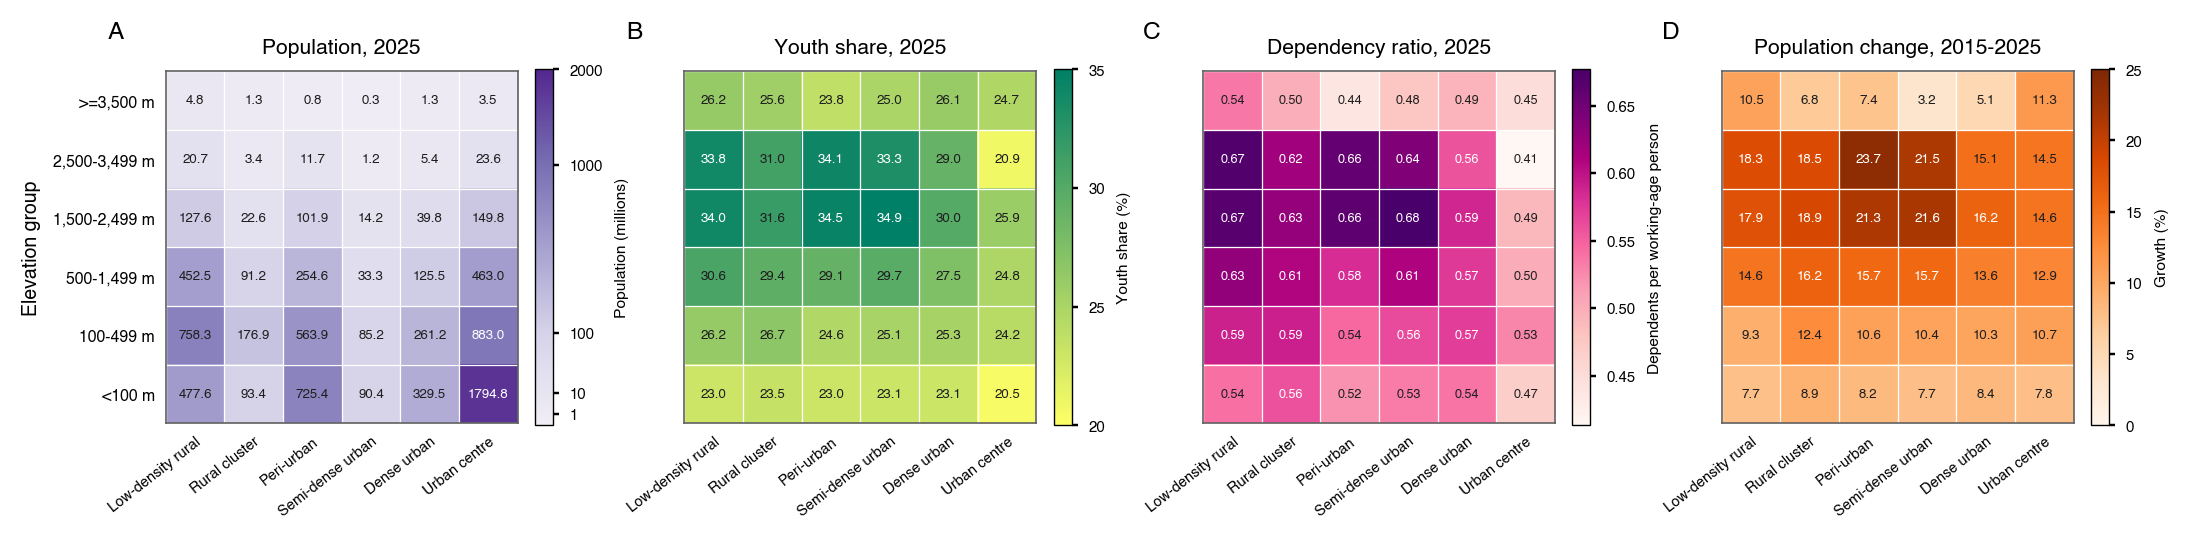

In [18]:
matrix_elev_order = list(reversed(ELEVATION_ORDER))
pop_mat = fig2_test.pivot(index='elevation_group', columns='settlement_class', values='population_2025_millions').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)
youth_mat = fig2_test.pivot(index='elevation_group', columns='settlement_class', values='youth_share_percent').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)
dependency_mat = fig2_test.pivot(index='elevation_group', columns='settlement_class', values='dependency_ratio').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)
growth_mat = fig2_test.pivot(index='elevation_group', columns='settlement_class', values='growth_static2025_percent').reindex(index=matrix_elev_order, columns=SETTLEMENT_ORDER)

population_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'population_lavender_purple',
    ['#F1EEF6', '#D7D4EA', '#A6A1CF', '#756BB1', '#54278F'],
)
dependency_cmap = mpl.cm.RdPu.copy()
growth_cmap = mpl.cm.Oranges.copy()

panels = [
    (pop_mat, 'Population, 2025', population_cmap, mpl.colors.PowerNorm(gamma=0.45, vmin=0, vmax=2000), '{:.1f}', 'Population (millions)', [1, 10, 100, 1000, 2000]),
    (youth_mat, 'Youth share, 2025', 'summer_r', mpl.colors.Normalize(vmin=20, vmax=35), '{:.1f}', 'Youth share (%)', [20, 25, 30, 35]),
    (dependency_mat, 'Dependency ratio, 2025' + ('*' if dependency_preview_note else ''), dependency_cmap, minmax_norm(dependency_mat), '{:.2f}', 'Dependents per working-age person', None),
    (growth_mat, 'Population change, 2015-2025', growth_cmap, mpl.colors.Normalize(vmin=0, vmax=25), '{:.1f}', 'Growth (%)', [0, 5, 10, 15, 20, 25]),
]

fig, axes = plt.subplots(1, 4, figsize=(9.6, 3.65), dpi=220, sharey=True)
fig.subplots_adjust(left=0.068, right=0.988, top=0.82, bottom=0.34, wspace=0.34)

for idx, (ax, data, title, cmap, norm, fmt, cbar_label, ticks) in enumerate(zip(axes, *zip(*panels))):
    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='equal')
    annotate_matrix(ax, data, cmap=cmap, norm=norm, fmt=fmt, fontsize=4.15 if idx == 2 else 4.35)
    ax.set_title(title)
    ax.set_xticks(np.arange(len(SETTLEMENT_ORDER)), SETTLEMENT_ORDER, rotation=38, ha='right', rotation_mode='anchor')
    ax.set_yticks(np.arange(len(matrix_elev_order)), [ELEVATION_LABELS[e] for e in matrix_elev_order])
    ax.tick_params(axis='x', length=0, labelsize=4.8)
    ax.tick_params(axis='y', length=0, labelleft=(idx == 0), labelsize=5.2)
    ax.set_xticks(np.arange(-0.5, len(SETTLEMENT_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(matrix_elev_order), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.42)
    ax.tick_params(which='minor', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.55)
        spine.set_color('0.38')
    if idx == 0:
        ax.set_ylabel('Elevation group')
    cbar_kwargs = {'fraction': 0.046, 'pad': 0.045}
    if ticks is not None:
        cbar_kwargs['ticks'] = ticks
    cbar = fig.colorbar(im, ax=ax, **cbar_kwargs)
    cbar.ax.tick_params(labelsize=4.9, length=2)
    cbar.outline.set_linewidth(0.45)
    cbar.set_label(cbar_label, fontsize=5.1)
    panel_label(ax, chr(ord('A') + idx))

if dependency_preview_note:
    fig.text(
        0.078, 0.055,
        '* Dependency panel is a layout preview: elevation-level dependency ratio is repeated across settlement classes.',
        ha='left', va='bottom', fontsize=5.4, color='0.25'
    )

plt.show()
